# Perpetrator Analysis in Sexual Assault Narratives

Uses `teanets` SVO extraction on r/sexualassault to identify **who** is described as perpetrating assault.

- Only `passive_approx=0` edges (genuine agent or passive with explicit "by"-phrase)
- Negated verbs removed ("do not rape", "never abuse")
- Verb phrases normalized to core lemma (`rape`, `abuse`, `assault`, `molest`)
- Agents normalized (possessive "i dad" → "dad")

In [1]:
import sys, os, re
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import teanets as tea
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

## 1. Load, Clean & Normalize

In [2]:
# ── 1. Load, Clean & Normalize ─────────────────────────────────────────
# Load SVO from comments and posts, combine and filter for genuine Agent→Event (passive_approx=0).
CSV_COMMENTS = '../data/svo_output/comments_svo.csv'
CSV_POSTS    = '../data/svo_output/posts_svo.csv'

svo_raw = pd.concat(
    [pd.read_csv(CSV_COMMENTS), pd.read_csv(CSV_POSTS)],
    ignore_index=True
)
print(f'SVO rows total: {len(svo_raw):,}')

# Keep only rows where passive_approx=0, Semantic-Syntactic=0, TEA=Agent and TEA2=Event
agents_events = svo_raw[
    (svo_raw['passive_approx'] == 0) &
    (svo_raw['Semantic-Syntactic'] == 0) &
    (svo_raw['TEA']  == 'Agent') &
    (svo_raw['TEA2'] == 'Event')
].copy()
print(f'Agent→Event (pa=0): {len(agents_events):,}')

# Retrieve Object (Target) if present for the same svo_id
targets = svo_raw[
    (svo_raw['TEA']  == 'Event') &
    (svo_raw['TEA2'] == 'Target')
][['svo_id', 'Node 2']].rename(columns={'Node 2': 'object'})

# Merge to get a DataFrame with Agent, Verb and Object (if any)
genuine = pd.merge(agents_events, targets, on='svo_id', how='left')

# Assault verbs to keep
_ASSAULT_VERBS = {'rape','abuse','assault','molest'}
_VERB_MAP = {
    'rape':'rape','raping':'rape','raped':'rape','rapes':'rape',
    'abuse':'abuse','abused':'abuse','abuses':'abuse','abusing':'abuse',
    'assault':'assault','assaulted':'assault','assaults':'assault','assaulting':'assault',
    'molest':'molest','molested':'molest','molests':'molest','molesting':'molest',
}

def core_verb(v):
    if not isinstance(v, str): return None
    v = v.lower().strip()
    return _VERB_MAP.get(v, None)

genuine['core_verb'] = genuine['Node 2'].apply(core_verb)
genuine = genuine.dropna(subset=['core_verb'])

def normalize_agent(a):
    if not isinstance(a, str): return ''
    a = a.lower().strip()
    a = re.sub(r'^(i|my|her|his|their|our)\s+', '', a)  # possessivo da coref
    a = re.sub(r'\b(old|older|younger|year|little|big|late)\b', '', a)
    return re.sub(r'\s+', ' ', a).strip()

genuine['agent'] = genuine['Node 1'].apply(normalize_agent)
assault = genuine[genuine['agent'] != ''].copy()
print(f'Assault (clean):    {len(assault):,}')

print('\nVerb distribution:')
display(assault.groupby('core_verb').size().rename('n').to_frame())

# Alias
svo_df = svo_raw


SVO rows total: 10,265,474
Agent→Event (pa=0): 2,270,075
Assault (clean):    315,173

Verb distribution:


,n
core_verb,
abuse,109804
assault,91954
molest,80851
rape,32564


## 2. Categorize Perpetrators

In [3]:
# ── 2. Categorize Perpetrators (relational category + gender + voice) ────────
import re

# ── Pronouns ───────────────────────────────────────────────────────────────────
_PRONOUNS_M = {'he', 'himself'}
_PRONOUNS_F = {'she', 'herself'}
_PRONOUNS_N = {
    'they', 'you', 'i', 'we', 'it', 'themselves', 'who', 'those',
    'someone', 'anyone', 'something', 'what', 'that', 'this'
}
_PRONOUNS = _PRONOUNS_M | _PRONOUNS_F | _PRONOUNS_N

# ── Male rules ──────────────────────────────────────────────────────────────────
_RULES_M = [
    ('Family',
     ['stepfather', 'grandfather', 'grandad', 'father-in-law',
      'brother-in-law', 'dad', 'father', 'brother', 'uncle', 'nephew']),

    ('Partner',
     ['ex-boyfriend', 'ex-husband', 'boyfriend', 'fiancé', 'husband']),

    ('Institutional/Authority',
     ['priest', 'pastor', 'monk']),

    ('Workplace',
     ['male coworker', 'male colleague']),

    ('Generic descriptor',
     ['guy', 'man', 'men', 'boy']),
]

# ── Female rules ──────────────────────────────────────────────────────────────
_RULES_F = [
    ('Family',
     ['stepmother', 'grandmother', 'granny', 'mother-in-law',
      'sister-in-law', 'mom', 'mother', 'sister', 'aunt', 'niece']),

    ('Partner',
     ['ex-girlfriend', 'ex-wife', 'girlfriend', 'fiancée', 'wife']),

    ('Institutional/Authority',
     ['nun']),

    ('Workplace',
     ['female coworker', 'female colleague']),

    ('Generic descriptor',
     ['lady', 'woman', 'women', 'girl']),
]

# ── Neutral rules ─────────────────────────────────────────────────────────────
_RULES_N = [
    ('Family',
     ['stepparent', 'grandparent', 'cousin', 'parent', 'sibling',
      'family member', 'relative']),

    ('Partner',
     ['ex-partner', 'ex-spouse', 'partner', 'spouse', 'ex', 'date',
      'fwb', 'hookup']),

    ('Social/Acquaintance',
     ['best friend', 'close friend', 'friend', 'classmate', 'peer',
      'neighbour', 'neighbor', 'roommate', 'acquaintance']),

    ('Institutional/Authority',
     ['teacher', 'professor', 'instructor', 'coach', 'counselor',
      'doctor', 'therapist', 'nurse', 'babysitter', 'tutor', 'mentor']),

    ('Institutional/Coercive',
     ['police', 'officer', 'cop', 'guard', 'soldier', 'military',
      'warden', 'agent']),

    ('Workplace',
     ['boss', 'manager', 'supervisor', 'coworker', 'colleague',
      'employer', 'intern']),

    ('Labeled perpetrator',
     ['predator', 'abuser', 'rapist', 'molester', 'assailant',
      'attacker', 'offender', 'perpetrator']),

    ('Generic descriptor',
     ['person', 'people', 'adult', 'individual', 'stranger']),
]


# ── Matching con word boundary ────────────────────────────────────────────────
def _match_rules(s: str, rules: list) -> str | None:
    for cat, kws in rules:
        for k in sorted(kws, key=len, reverse=True):   # match longest first to avoid partial matches
            if re.search(rf'\b{re.escape(k)}\b', s):
                return cat
    return None


def categorize_full(s: str) -> tuple[str, str]:
    """Return (category, gender) for a given agent string."""
    if s in _PRONOUNS_M:
        return ('Pronoun / Vague', 'Masculine')
    if s in _PRONOUNS_F:
        return ('Pronoun / Vague', 'Feminine')
    if s in _PRONOUNS_N:
        return ('Pronoun / Vague', 'Neutral')

    cat = _match_rules(s, _RULES_M)
    if cat:
        return (cat, 'Masculine')

    cat = _match_rules(s, _RULES_F)
    if cat:
        return (cat, 'Feminine')

    cat = _match_rules(s, _RULES_N)
    if cat:
        return (cat, 'Neutral')

    return ('Other', 'Neutral')


# ── Apply categorization ──────────────────────────────────────────────────
assault[['cat', 'gender']] = assault['agent'].apply(
    lambda s: pd.Series(categorize_full(s))
)

# Voice: active vs passive
assault['voice'] = assault['is_passive'].apply(
    lambda x: 'Passive' if x == 1 else 'Active'
)

# ── Print distributions ──────────────────────────────────────────────────────
cat_counts = assault['cat'].value_counts()
cat_pct    = (100 * cat_counts / len(assault)).round(1)

print(f'Total edges assault: {len(assault):,}')
print('\nCategory distribution:')
display(pd.DataFrame({'n': cat_counts, '%': cat_pct}))

gender_counts = assault['gender'].value_counts()
gender_pct    = (100 * gender_counts / len(assault)).round(1)
print('\nDistribution of agent gender:')
display(pd.DataFrame({'n': gender_counts, '%': gender_pct}))

voice_counts = assault['voice'].value_counts()
voice_pct    = (100 * voice_counts / len(assault)).round(1)
print('\nDistribution of voice (active vs passive):')
display(pd.DataFrame({'n': voice_counts, '%': voice_pct}))

Total edges assault: 315,173

Category distribution:


,n,%
cat,,
Pronoun / Vague,183196,58.1
Other,41444,13.1
Family,36170,11.5
Generic descriptor,32121,10.2
Partner,8875,2.8
Social/Acquaintance,7966,2.5
Labeled perpetrator,2424,0.8
Institutional/Authority,2146,0.7
Workplace,552,0.2



Distribution of agent gender:


,n,%
gender,,
Neutral,228716,72.6
Masculine,68000,21.6
Feminine,18457,5.9



Distribution of voice (active vs passive):


,n,%
voice,,
Active,261818,83.1
Passive,53355,16.9


## 3. Named Perpetrators (excluding pronouns & vague references)

Only relational and generic descriptors — the actors that reveal **social structure** of assault.

In [4]:
named = assault[assault['cat'] != 'Pronoun / Vague'].copy()
print(f'Named perpetrator edges: {len(named):,} ({100*len(named)/len(assault):.1f}% of assault edges)')

# Category breakdown
named_cats = named['cat'].value_counts()

# Top individual agents
print('\nTop 25 named perpetrators:')
display(named['agent'].value_counts().head(25).to_frame('n'))

Named perpetrator edges: 131,977 (41.9% of assault edges)

Top 25 named perpetrators:


,n
agent,
guy,9089
brother,5255
man,4883
dad,4392
people,3240
cousin,3194
father,3062
friend,2654
family member,2463


## 4. Perpetrator–Verb Network

Relational perpetrators (Family, Social, Institutional) connected to their assault verbs.

Showing 62823 edges between the Top 10 nodes per category.


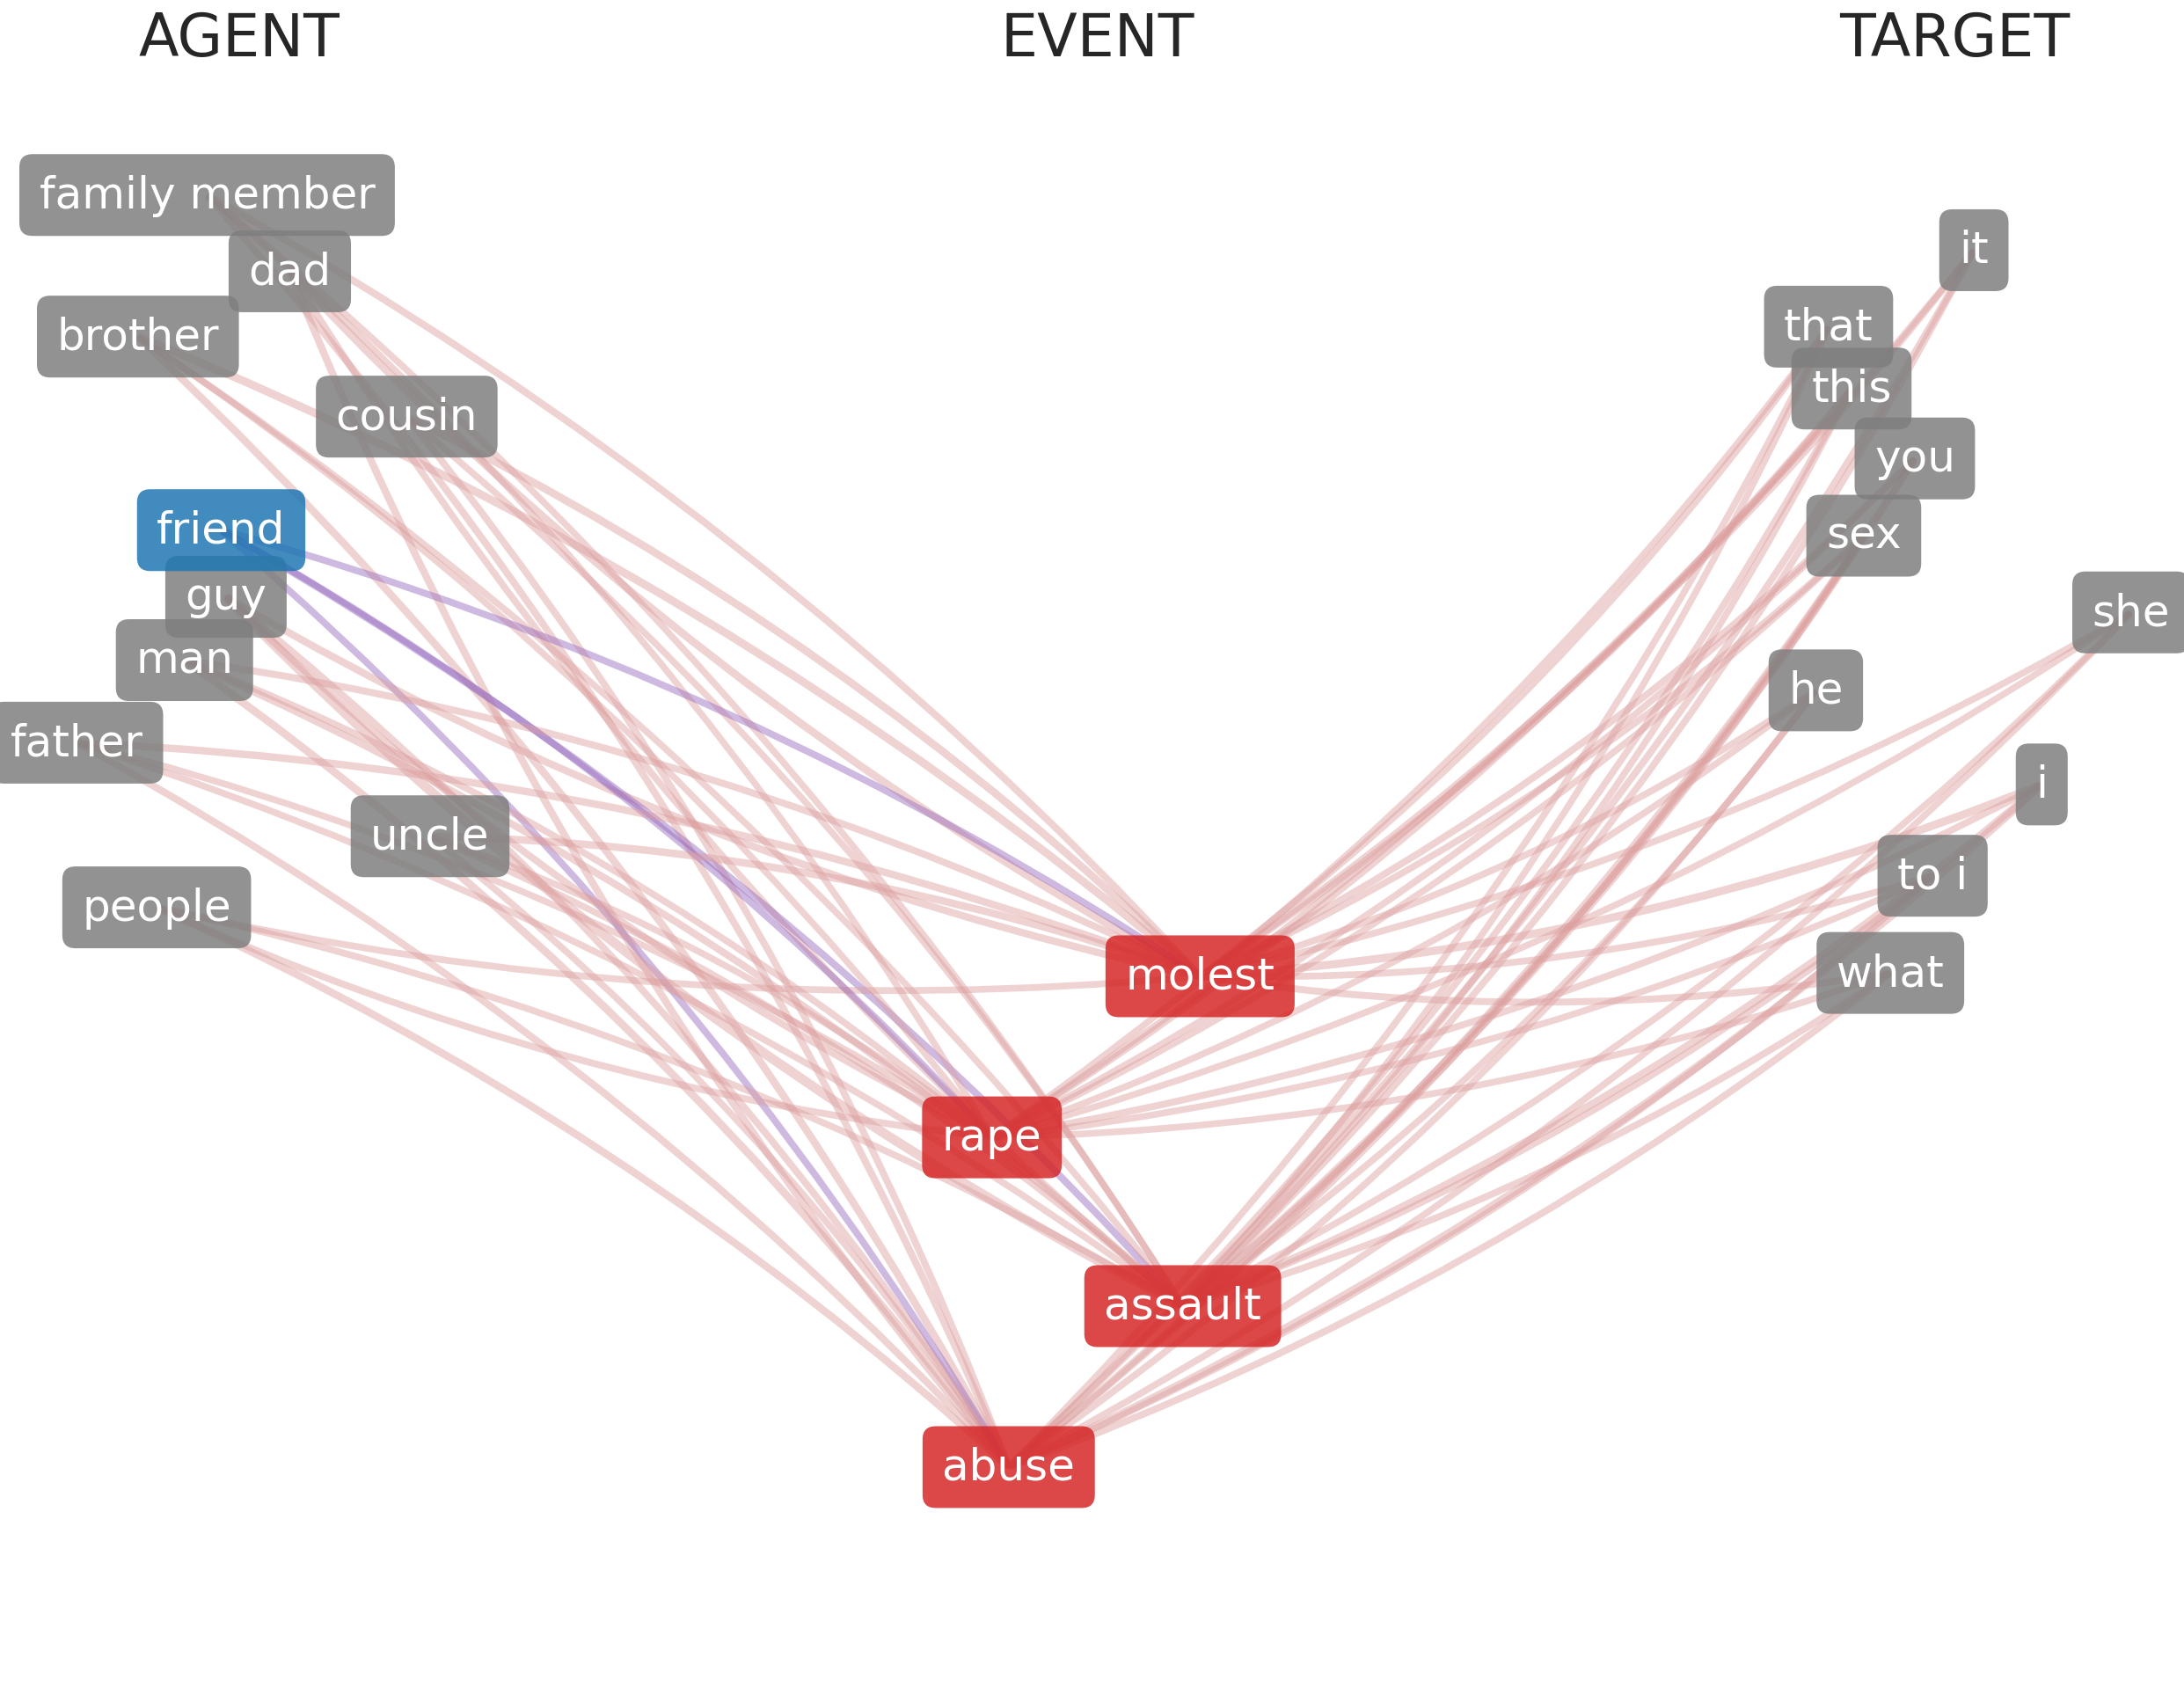

In [5]:
# 1. Filter out pronouns to focus on named perpetrators
assault = assault[assault['cat'] != 'Pronoun / Vague'].copy()

#  Top N configuration
TOP_N = 10 

# 2. Identify Top N using normalized columns (cleaner)
top_agents  = assault['agent'].value_counts().head(TOP_N).index
top_verbs   = assault['core_verb'].value_counts().head(TOP_N).index
top_objects = assault['object'].dropna().value_counts().head(TOP_N).index

# 3. To create a tripartite graph, we need to construct edges for both Agent→Verb and Verb→Object, but only if both nodes are in the respective Top N lists.

# A arc Agent -> Verb (only if BOTH are top)
df_av = assault[
    assault['agent'].isin(top_agents) & 
    assault['core_verb'].isin(top_verbs)
].copy()
df_av['Node 1'] = df_av['agent']
df_av['Node 2'] = df_av['core_verb']

# B arc Verb -> Object (only if BOTH are top)
df_vo = assault[
    assault['core_verb'].isin(top_verbs) & 
    assault['object'].isin(top_objects)
].copy()
df_vo['Node 1'] = df_vo['core_verb']
df_vo['TEA']    = 'Event'
df_vo['Node 2'] = df_vo['object']
df_vo['TEA2']   = 'Target'

# 4. Combine edges for plotting
graph_df = pd.concat([df_av, df_vo], ignore_index=True)

print(f'Showing {len(graph_df)} edges between the Top {TOP_N} nodes per category.')

# 5. Plot the graph using teaplot
import teanets.teaplot as teaplot
teaplot.plot_svo_graph(
    graph_df,
    custom_font=30,
    filename='../data/svo_output/tripartite_network_top.png',
    mark_passive_approx=True
)


In [6]:
## python -m teanets.batch_extract --gpu --batch-size 50 --sample-size 500 --seed 42 --output-dir ../data/svo_output --input ../data/sexualassault.csv

In [7]:
# ── Active / Passive Analysis ──────────────────────────────────

# Voice: already calculated in the previous cell as column 'voice'
active  = assault[assault['voice'] == 'Active'].copy()
passive = assault[assault['voice'] == 'Passive'].copy()

print(f"Active:  {len(active):,} edge ({100*len(active)/len(assault):.1f}%)")
print(f"Passive: {len(passive):,} edge ({100*len(passive)/len(assault):.1f}%)")

# Save the two subsets to CSV
active.to_csv('../data/svo_output/agents_active.csv',  index=False)
passive.to_csv('../data/svo_output/agents_passive.csv', index=False)
print("\nFile saved: agents_active.csv, agents_passive.csv")

# Top 10 agents in active vs passive voice
for label, df in [('ACTIVE', active), ('PASSIVE', passive)]:
    agents = df['agent'].value_counts().head(25)
    print(f"\nTop 10 agents [{label}]:")
    display(agents.to_frame('n'))

# ── Distribution Gender × Voice ──────────────────────────────────────────
print("\n── Gender × Voice ──")
cross = assault.groupby(['gender','voice']).size().unstack(fill_value=0)
cross['TOTALE'] = cross.sum(axis=1)
display(cross)

Active:  81,961 edge (62.1%)
Passive: 50,016 edge (37.9%)

File saved: agents_active.csv, agents_passive.csv

Top 10 agents [ACTIVE]:


,n
agent,
guy,8149
dad,3108
people,3036
man,2983
brother,2283
father,1686
woman,1409
cousin,1369
uncle,1275



Top 10 agents [PASSIVE]:


,n
agent,
brother,2972
family member,1958
man,1900
cousin,1825
friend,1554
father,1376
dad,1284
uncle,948
guy,940



── Gender × Voice ──


voice,Active,Passive,TOTALE
gender,,,
Feminine,6296,3824,10120
Masculine,28234,17069,45303
Neutral,47431,29123,76554
